<a href="https://colab.research.google.com/github/sajidan1104/Mall-Customers-KMeans/blob/main/KMeans_Mall_Customers_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Membaca data Mall Customers
# Pastikan file Mall_Customers.csv sudah di-upload ke Colab
df = pd.read_csv("Mall_Customers.csv")

# Menampilkan 5 baris pertama dan info dataset
print("Tampilan Data Awal:")
display(df.head())
print("\nInfo Dataset:")
df.info()

Tampilan Data Awal:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


code diatas memuat pustaka yang dibutuhkan dan membaca dataset. Dataset ini memiliki 5 kolom: CustomerID, Gender, Age, Annual Income (k$), dan Spending Score (1-100)

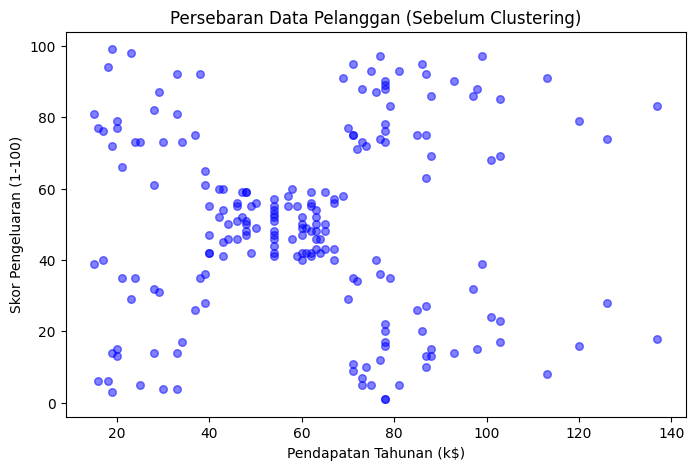

In [2]:
# Kita hanya mengambil kolom 'Annual Income' dan 'Spending Score'
# Kolom tersebut ada di index 3 dan 4
df_x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Memvisualkan persebaran data sebelum dikluster
plt.figure(figsize=(8,5))
plt.scatter(df_x['Annual Income (k$)'], df_x['Spending Score (1-100)'], s=30, c="blue", alpha=0.5)
plt.title("Persebaran Data Pelanggan (Sebelum Clustering)")
plt.xlabel("Pendapatan Tahunan (k$)")
plt.ylabel("Skor Pengeluaran (1-100)")
plt.show()

Algoritma Machine Learning tidak butuh CustomerID (karena hanya nomor urut) dan Gender (karena berupa teks). Jadi, kita hanya mengambil fitur numerik yang relevan. Jika Anda melihat plot hasil cell ini, Anda akan samar-samar melihat ada 5 kelompok titik data yang terpisah.

In [3]:
# Mengubah dataframe menjadi array numpy
x_array = np.array(df_x)

# Normalisasi data menggunakan MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)

print("Data setelah discaling (5 baris pertama):")
print(x_scaled[:5])

Data setelah discaling (5 baris pertama):
[[0.         0.3877551 ]
 [0.         0.81632653]
 [0.00819672 0.05102041]
 [0.00819672 0.7755102 ]
 [0.01639344 0.39795918]]


Karena rentang nilai pendapatan dan rentang skor pengeluaran bisa berbeda skalanya, kita gunakan MinMaxScaler agar semua nilai berada di rentang 0 hingga 1. Ini membuat K-Means lebih akurat saat menghitung jarak (Euclidean Distance).

In [4]:
# Membuat model KMeans dengan 5 klaster
# n_init='auto' disarankan pada versi sklearn terbaru
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Training model menggunakan data yang sudah discaling
kmeans.fit(x_scaled)

# Menambahkan hasil cluster ke dataframe asli
df["Kluster"] = kmeans.labels_

print("Data dengan label Kluster:")
display(df.head())

Data dengan label Kluster:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Kluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,0
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4


Kita menetapkan n_clusters=5. Model K-Means akan mencari 5 titik pusat (centroid) terbaik dan mengelompokkan data. Hasilnya disimpan dalam kolom baru bernama Kluster (berisi angka 0 sampai 4).

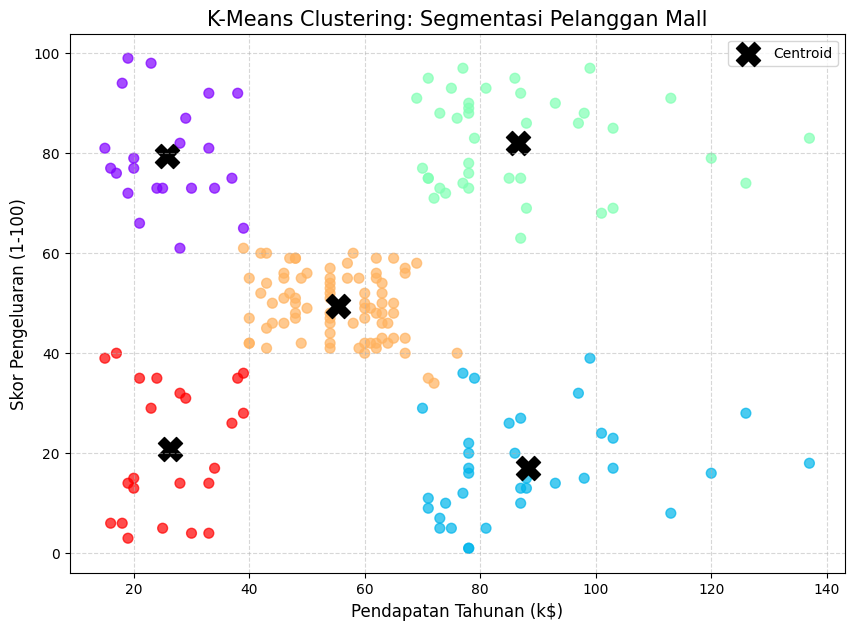

In [5]:
plt.figure(figsize=(10,7))

# Plot hasil clustering dengan warna yang berbeda untuk setiap klaster
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                      c=df['Kluster'], cmap='rainbow', s=50, alpha=0.7)

# Mengembalikan skala centroid ke nilai asli untuk ditampilkan di plot
centroids_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot Centroid (titik pusat tiap klaster)
plt.scatter(
    centroids_original_scale[:, 0],
    centroids_original_scale[:, 1],
    s=300, c='black', marker='X', label='Centroid'
)

plt.title('K-Means Clustering: Segmentasi Pelanggan Mall', fontsize=15)
plt.xlabel('Pendapatan Tahunan (k$)', fontsize=12)
plt.ylabel('Skor Pengeluaran (1-100)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Plot dengan 5 kelompok warna berbeda beserta tanda "X" hitam di tengah-tengahnya (Centroid). Berikut adalah interpretasi bisnis dari hasil K-Means tersebut:

    Klaster Kiri Bawah (Pendapatan Rendah, Pengeluaran Rendah):
    Pelanggan yang berpenghasilan kecil dan berhemat di mall.

    Klaster Kiri Atas (Pendapatan Rendah, Pengeluaran Tinggi):
    Pelanggan berpenghasilan kecil namun sangat konsumtif (boros). Biasanya anak muda atau mahasiswa.

    Klaster Tengah (Pendapatan Sedang, Pengeluaran Sedang):
    Pelanggan rata-rata. Penghasilan dan pengeluarannya seimbang (Ini kelompok yang paling padat/banyak).

    Klaster Kanan Bawah (Pendapatan Tinggi, Pengeluaran Rendah):
    Pelanggan kaya raya yang sangat berhati-hati dalam berbelanja (suka menabung). Target yang bagus untuk produk investasi atau barang kebutuhan esensial premium.

    Klaster Kanan Atas (Pendapatan Tinggi, Pengeluaran Tinggi):
    Target Market Utama! Pelanggan kaya yang sangat suka berbelanja.